# 基于字符级 RNN 的莎士比亚文本生成

本 Notebook 演示如何使用字符级循环神经网络（Char-RNN）学习莎士比亚剧本的字符分布，并自回归生成风格相近的英文文本。核心流程包括：数据预处理与词表构建、CharRNN 模型定义、训练与检查点保存、温度采样推理。

实际是从序列中学习「给定前文，预测下一个字符」的规律；训练完成后，以提示字符串为种子，结合 RNN 隐藏状态自回归地逐字符采样生成文本。

In [5]:
import matplotlib as mpl  # 导入 matplotlib 基础模块，用于全局绘图配置
import matplotlib.pyplot as plt  # 导入绘图子模块，提供 MATLAB 风格的绘图 API
%matplotlib inline  
# Jupyter 魔法命令：将图表直接内嵌在 notebook 输出区域显示
import numpy as np  # 导入 NumPy，提供高性能多维数组运算，别名 np 是约定俗成的写法
import sklearn  # 导入 scikit-learn，机器学习工具库，此处仅用于打印版本号验证环境
import pandas as pd  # 导入 Pandas，提供 DataFrame 等结构化数据处理能力，别名 pd
import os  # 导入标准库 os，用于文件路径操作、目录创建等操作系统接口
import sys  # 导入标准库 sys，用于访问 Python 解释器版本等运行时信息
import time  # 导入标准库 time，用于计时和时间延迟操作
from tqdm import tqdm  # 从 tqdm 库导入自适应进度条，auto 模式可自动适配终端或 Jupyter 环境
import torch  # 导入 PyTorch 深度学习框架核心模块
import torch.nn as nn  # 导入神经网络模块，包含 Linear、RNN、Embedding 等常用层
import torch.nn.functional as F  # 导入函数式 API，提供 softmax、relu 等无状态的计算函数

print(sys.version_info)  # 打印当前 Python 解释器的版本信息，形如 (major=3, minor=x, ...)
for module in mpl, np, pd, sklearn, torch:  # 遍历所有关键依赖库，逐一打印版本号以验证环境一致性
    print(module.__name__, module.__version__)  # __name__ 为模块名字符串，__version__ 为版本号字符串
    
# 自动选择计算设备：优先使用 GPU（cuda:0），若无 GPU 则回退到 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印最终使用的设备，用于确认是否成功使用 GPU 加速

seed = 42  # 设置随机种子为 42，是机器学习领域常用的约定值，保证实验结果可复现
torch.manual_seed(seed)  # 固定 CPU 上 PyTorch 的随机数生成器种子
torch.cuda.manual_seed_all(seed)  # 固定所有 GPU 上的随机数生成器种子，多卡训练时也生效

sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 一、数据准备

In [6]:
# !wget https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt
# 上面这行被注释掉的命令用于在 Linux/Mac 环境中通过 wget 工具从 Google 官方存储桶
# 下载莎士比亚全集文本文件（约 1.1 MB），本地已存在该文件时无需再次执行

In [7]:
# 数据来源：Google 提供的莎士比亚全集文本，可通过上面的 wget 命令下载
# 以只读模式（"r"）和 UTF-8 编码打开本地文件，确保非 ASCII 字符（如引号）正确解码
with open("data/shakespeare.txt", "r", encoding="utf8") as file:
    text = file.read()  # 一次性将整个文件内容读入内存，返回类型为 str

# 打印文本总字符数，了解数据集规模（约 110 万字符）
print("length", len(text))
# 打印前 100 个字符，快速预览文本内容与格式（剧本风格：角色名 + 台词）
print(text[0:100])

length 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


### 1.1 构造字符词表与索引映射

In [8]:
# 文本生成模型的核心步骤说明：
# 1. 从原始文本中提取词表（vocab）：所有不重复字符的集合
# 2. 建立字符→整数的映射（char2idx），便于将文本转换为模型可处理的数字序列
# 3. 将整个文本转换为整数 ID 序列（text_as_int）
# 4. 构造训练样本：输入序列 [a,b,c,d] → 目标序列 [b,c,d,EOS]，即每个位置预测下一个字符

# set(text) 去重得到所有出现过的字符，sorted 排序使词表顺序确定且可复现
# 排序后的结果是一个 list，包含 65 个独立字符（包括字母、标点、换行等）
vocab = sorted(set(text))
print(len(vocab))   # 打印词表大小，即模型的"字母表"中共有多少种字符
print(vocab)        # 打印词表内容，直观展示所有字符种类

65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [9]:
# 演示 Python 内置 enumerate() 函数的用法
# enumerate(iterable) 返回一个枚举对象，每次迭代产生 (index, value) 元组
# 这里 idx 是从 0 开始的整数索引，char 是对应的字符值
# 此用法是后续构建 char2idx 字典的基础
for idx, char in enumerate(['h', 'o', 'w']):
    print(idx, char)  # 输出：索引（int） + 字符（str），中间以空格分隔

0 h
1 o
2 w


In [10]:
# 使用字典推导式构建"字符→整数索引"的映射表
# enumerate(vocab) 同时返回索引 idx（int）和字符 char（str）
# 映射关系：char 作为键，idx 作为值，即 char2idx[字符] = 整数ID
# 有了这张表，就可以把任意字符快速转换为对应的整数，便于送入神经网络
char2idx = {char: idx for idx, char in enumerate(vocab)}
print(char2idx)  # 打印字典，验证每个字符都有唯一对应的整数编号（共 65 个条目）

{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}


In [11]:
# 构建"整数索引→字符"的反向映射表
# np.array(vocab) 将 list 转换为 NumPy 数组，类型为 dtype('<U1')（单字符 Unicode）
# 使用 NumPy 数组而非列表的优势：支持向量化索引，如 idx2char[[3,5,7]] 可一次取多个字符
# 推理时，模型输出的整数 ID 可通过 idx2char[id] 快速还原为对应字符
idx2char = np.array(vocab)
print(idx2char)  # 打印数组，验证索引 0→'\n'、索引 1→' '、索引 13→'A' 等映射关系

['\n' ' ' '!' '$' '&' "'" ',' '-' '.' '3' ':' ';' '?' 'A' 'B' 'C' 'D' 'E'
 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W'
 'X' 'Y' 'Z' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o'
 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


### 1.2 文本整数化编码

In [12]:
# 利用列表推导式将整个原始文本转换为整数 ID 序列
# char2idx[c] 查字典，返回字符 c 对应的整数索引（int）
# np.array(...) 将列表包装成 NumPy 数组（dtype=int64），便于后续切片操作
text_as_int = np.array([char2idx[c] for c in text])
print(text_as_int.shape)   # 输出数组形状，应为 (1115394,)，即与 text 等长
print(len(text_as_int))    # 再次确认总字符数与原文本字符数一致
print(text_as_int[0:10])   # 打印前 10 个整数 ID，对照原文 "First Citi" 验证编码正确性
print(text[0:10])          # 打印原文前 10 个字符，与上行整数 ID 对应查看

(1115394,)
1115394
[18 47 56 57 58  1 15 47 58 47]
First Citi


In [13]:
# 计算在序列长度为 101（100个输入字符 + 1个对齐偏移字符）的设定下，
# 整个语料库最多能切出多少个不重叠的训练样本
# 1115394 // 101 = 11043 个完整样本，末尾不足 101 的部分直接丢弃
1115394 // 101

11043

### 1.3 构建字符级数据集与数据加载器

In [14]:
from torch.utils.data import Dataset, DataLoader  # Dataset 是自定义数据集的基类，DataLoader 负责批次化加载

class CharDataset(Dataset):
    """字符级文本数据集，将长文本按固定窗口切割为训练样本。"""

    def __init__(self, text_as_int, seq_length):
        """
        参数：
            text_as_int (np.ndarray): 已编码为整数 ID 的文本序列，shape=(N,)
            seq_length (int): 每个训练样本的输入序列长度（不含对齐偏移字符）
        """
        self.sub_len = seq_length + 1  # 每个原始片段长度 = 输入长度 + 1 个对齐偏移字符
        self.text_as_int = text_as_int  # 存储完整整数 ID 序列，供索引时切片
        self.num_seq = len(text_as_int) // self.sub_len  # 向下取整，得到不重叠样本总数

    def __getitem__(self, index):
        """
        根据索引返回第 index 个原始片段（长度为 sub_len）。
        参数：
            index (int): 样本索引，范围 [0, num_seq)
        返回：
            np.ndarray: 长度为 sub_len 的整数 ID 子序列，前 seq_length 位为输入，最后 1 位为对齐偏移字符
        """
        return self.text_as_int[index * self.sub_len: (index + 1) * self.sub_len]

    def __len__(self):
        """返回数据集中样本总数（int），供 DataLoader 计算批次数量使用。"""
        return self.num_seq


def collat_fct(batch):
    """
    DataLoader 的自定义整理函数，将一批原始片段拆分为（输入序列，目标序列）对。
    字符级语言模型的训练目标是：给定当前字符序列，预测每个位置的下一个字符。

    参数：
        batch (list of np.ndarray): 长度为 batch_size 的列表，每个元素是长度 sub_len 的整数序列

    返回：
        tuple(torch.Tensor, torch.Tensor):
            src: shape=(batch_size, seq_length)，输入序列（去掉最后一位），dtype=int64
            trg: shape=(batch_size, seq_length)，目标序列（去掉第一位），dtype=int64
    """
    src_list = []  # 存放所有样本的输入序列（每条长度为 seq_length）
    trg_list = []  # 存放所有样本的目标序列（每条长度为 seq_length，向右偏移 1 位）
    for part in batch:
        src_list.append(part[:-1])  # 取前 seq_length 个字符作为输入（去掉最后 1 位）
        trg_list.append(part[1:])   # 取后 seq_length 个字符作为目标（去掉第一位，整体右移 1 位）

    src_list = np.array(src_list)  # list → NumPy 数组，shape=(batch_size, seq_length)
    trg_list = np.array(trg_list)  # list → NumPy 数组，shape=(batch_size, seq_length)
    # 转为 PyTorch int64 张量；int64 是 nn.Embedding 查表所必须的整数类型
    return (
        torch.Tensor(src_list).to(dtype=torch.int64),
        torch.Tensor(trg_list).to(dtype=torch.int64)
    )


# 实例化数据集：每个训练样本含 100 个输入字符（seq_length=100），原始片段长度为 101
train_ds = CharDataset(text_as_int, 100)
# 实例化 DataLoader：batch_size=64，shuffle=True 每 epoch 打乱顺序，collate_fn 完成 src/trg 拆分
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collat_fct)

In [15]:
# 验证 DataLoader 输出的张量形状是否符合预期
# 迭代一次 train_dl，取出第一个批次后立即 break，避免遍历全部数据
for datas, labels in train_dl:
    print(datas.shape)   # 预期输出 torch.Size([64, 100])：64 个样本，每个 100 个输入字符 ID
    print(labels.shape)  # 预期输出 torch.Size([64, 100])：64 个样本，每个 100 个目标字符 ID（右移 1 位）
    break

torch.Size([64, 100])
torch.Size([64, 100])


## 二、模型定义

### 2.1 CharRNN 模型定义

In [16]:
class CharRNN(nn.Module):
    """字符级循环神经网络模型，用于序列到序列的字符预测任务。"""

    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=1024):
        """
        参数：
            vocab_size (int): 词表大小，即字符种类总数（本例为 65）
            embedding_dim (int): 字符嵌入维度，每个字符 ID 映射为的稠密向量长度，默认 256
            hidden_dim (int): RNN 隐藏层维度，控制模型的记忆容量，默认 1024
        """
        super().__init__()  # 调用父类 nn.Module 的构造函数，初始化模块注册机制
        # nn.Embedding：查找表，输入整数 ID，输出对应的稠密嵌入向量
        # 参数：vocab_size（词表大小）× embedding_dim（嵌入维度），共 65×256=16640 个参数
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # nn.RNN：单向单层循环神经网络
        # 输入维度 embedding_dim，隐藏维度 hidden_dim
        # batch_first=True 表示输入张量格式为 (batch_size, seq_len, features)，符合直觉
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        # nn.Linear：全连接输出层，将 RNN 每个时间步的隐藏状态映射到词表大小的 logits
        # 构造参数 in_features (int)：输入特征维度，须与 RNN 输出的最后一维 hidden_dim 一致，本例 1024
        # 构造参数 out_features (int)：输出特征维度，等于词表大小 vocab_size，本例 65
        # 可学习参数 weight：形状 (out_features, in_features) = (vocab_size, hidden_dim)
        # 可学习参数 bias：形状 (out_features,) = (vocab_size,)
        # ⚠️ 三维输入机制：nn.Linear 只对「最后一维」做 y = xW^T + b，前面所有维度视为 batch 维
        #   因此既可接收 (batch, hidden_dim)，也可直接接收 (batch, seq_len, hidden_dim)，无需手动 reshape
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        前向传播：对输入字符序列逐时间步计算下一个字符的 logits。

        参数：
            x (torch.Tensor): 整数 ID 输入序列，shape=(batch_size, seq_len)，dtype=int64
            hidden (torch.Tensor, optional): 上一时间步传入的隐藏状态，
                shape=(num_layers, batch_size, hidden_dim)；None 表示初始化为全零

        返回：
            tuple(torch.Tensor, torch.Tensor):
                x: shape=(batch_size, seq_len, vocab_size)，每个位置的字符预测 logits
                hidden: shape=(1, batch_size, hidden_dim)，最后时间步的隐藏状态，可用于有状态推理
        """
        # Embedding 查表：整数 ID → 浮点嵌入向量
        # (batch_size, seq_len) → (batch_size, seq_len, embedding_dim) 即 (64, 100, 256)
        x = self.embedding(x)
        # ── nn.RNN 第二个参数 hx（本函数形参 hidden）接口说明 ──
        # 调用形式：output, hidden = self.rnn(x, hx)   ← 第一个参数即下方 embedding 后的 x，第二个参数即形参 hidden
        # 功能：hx 是「本次前向开始之前」的初始隐藏状态 h_{t-1}，RNN 从该状态继续递推
        #   递推公式：h_t = tanh(W_ih · x_t + W_hh · h_{t-1} + b)
        #   - hx=None：PyTorch 自动初始化为全零，表示当前输入序列没有来自外部的历史记忆
        #   - hx 传入非 None 值：须为 torch.Tensor，内容是上一轮 self.rnn 返回的 hidden（隐藏状态 h_{t-1}），
        #     用于跨多次 forward 调用接续记忆；单次 self.rnn(x, hx) 内部的逐时间步递推由 PyTorch 自动完成，无需手动逐步传入
        #
        # hx 的 shape 必须为 (num_layers, batch_size, hidden_dim)：
        #   - num_layers：RNN 层数；本模型为单层 nn.RNN，故 num_layers=1
        #   - batch_size：须与第一个参数 x 的第 0 维（batch 维）相同
        #       x 此处是 embedding 之后的张量，shape=(batch_size, seq_len, embedding_dim)
        #       训练时 datas 经 embedding 后 x 为 (64, 100, 256)，故 hx 的 batch_size=64
        #       推理 generate_text 每步 input_eval 经 embedding 后 x 为 (1, 1, 256)，故 hx 的 batch_size=1
        #   - hidden_dim：必须与构造 nn.RNN(hidden_size=...) 一致，本例为 1024
        #   示例：训练 → hx 为 (1, 64, 1024)；自回归生成 → hx 为 (1, 1, 1024)
        #
        # 返回值（均相对本次传入的 x 而言）：
        #   - output：shape=(batch_size, seq_len, hidden_dim)，x 中每个时间步的隐状态
        #   - hidden：shape=(1, batch_size, hidden_dim)，x 最后一个时间步的隐状态
        #
        # ── 训练 vs 推理：何时传 hx、何时必须传 None ──
        # 【本 notebook 训练】train_dl 设置了 shuffle=True，且 training(..., stateful=False)
        #   因此每批前向都写 model(datas, hidden=None)，不能把上一批的 hidden 传进来。原因：
        #   1) DataLoader 打乱后，当前 batch 的 64 条样本来自原文不同位置，彼此在文本上不连续
        #   2) 若传入上一批的 hidden，其 shape 为 (1, 64, 1024)，第 i 条 hidden 对应的是
        #      「上一批第 i 条样本」读完后的记忆；但打乱后，当前批第 i 条已是完全不同的文本片段
        #   3) 把错误的 hidden 当初始状态，等于让模型带着「别人的前文」去读当前片段，语义错位，
        #      梯度信号被污染，训练不稳定且不符合「每个窗口独立预测下一字符」的监督设定
        #   4) 每个训练样本本身已含 seq_length=100 个字符，单批内 RNN 会在 100 步内从零隐状态
        #      递推并学完整窗口内的依赖，不依赖跨 batch 的 hidden 也足够
        # 【若要用 stateful=True 跨 batch 传 hidden】须同时满足：shuffle=False、样本按原文顺序
        #   逐批取出，且通常约定「上一批第 i 条样本的结尾」紧接「当前批第 i 条样本的开头」
        #   （本 CharDataset 按 101 字符切块、块间不重叠，一般仍用 stateful=False 更简单稳妥）
        # 【推理 generate_text】每步只输入 1 个新字符，必须把上一轮返回的 hidden 传入，否则每步
        #   都重置为零，模型无法记住已生成的上下文，输出会完全失去连贯性
        output, hidden = self.rnn(x, hidden)
        # 全连接层：对每个时间步的隐状态独立映射到词表 logits（序列标注式逐位置预测）
        # 输入 output：形状 (batch_size, seq_len, hidden_dim)，如 (64, 100, 1024)
        #   最后一维 hidden_dim=1024 须等于 self.fc.in_features；前两维为 batch 与序列长度，被 Linear 当作批量维
        # 输出 x：形状 (batch_size, seq_len, vocab_size)，如 (64, 100, 65)
        #   等价于将 output reshape 为 (batch_size*seq_len, hidden_dim)，过 fc 后再 reshape 回来
        #   即 64×100=6400 个隐状态向量共享同一套 fc 权重，各自从 1024 维映射到 65 维 logits
        # 与分类任务对比：分类通常只取末时间步 (batch, hidden_dim) 再进 fc；生成任务需每个位置都有预测
        x = self.fc(output)
        return x, hidden  # 返回 logits（用于损失计算）和隐藏状态（用于有状态推理）


vocab_size = len(vocab)  # 词表大小 = 65，作为模型输入/输出维度的关键超参数

# 打印模型各层参数名称及参数量，验证模型结构是否与理论计算一致
print("{:=^80}".format(" 一层单向 RNN "))  # 使用 format 居中打印分隔符
for key, value in CharRNN(vocab_size).named_parameters():
    # key: 参数名称字符串，如 'embedding.weight'
    # value: 参数张量，np.prod(value.shape) 计算其元素总数（即参数量）
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

=================================== 一层单向 RNN ===================================
            embedding.weight            paramerters num: 16640
            rnn.weight_ih_l0            paramerters num: 262144
            rnn.weight_hh_l0            paramerters num: 1048576
             rnn.bias_ih_l0             paramerters num: 1024
             rnn.bias_hh_l0             paramerters num: 1024
               fc.weight                paramerters num: 66560
                fc.bias                 paramerters num: 65


### 2.2 模型参数验证与前向传播测试

In [13]:
# 手动验证各层参数量的理论计算结果，与上方 named_parameters 打印的数字逐一对照
print(65 * 256)    # Embedding 层参数量：vocab_size × embedding_dim = 65×256 = 16640
print(256 * 1024)  # RNN 输入权重（weight_ih_l0）：embedding_dim × hidden_dim = 256×1024 = 262144
print(1024 * 1024) # RNN 隐状态权重（weight_hh_l0）：hidden_dim × hidden_dim = 1024×1024 = 1048576
1024 * 65          # 全连接层权重（fc.weight）：hidden_dim × vocab_size = 1024×65 = 66560

16640
262144
1048576


66560

In [14]:
# 构造随机输入张量来端到端验证模型的前向传播
# torch.randint(low=0, high=vocab_size, size)：生成范围 [0, vocab_size) 内的随机整数张量
# shape=(3, 100) 表示 3 个样本，每个样本长度为 100 个字符 ID
sample_inputs = torch.randint(0, vocab_size, (3, 100))
print(sample_inputs.shape)  # 输出 torch.Size([3, 100])，确认输入形状正确

model = CharRNN(vocab_size)  # 实例化 CharRNN 模型，使用默认 embedding_dim=256、hidden_dim=1024
output = model(sample_inputs)  # 执行一次前向传播，返回 (logits, hidden) 元组
output[0].shape  # 查看 logits 的形状，预期为 (3, 100, 65) = (batch, seq_len, vocab_size)

torch.Size([3, 100])


torch.Size([3, 100, 65])

In [15]:
# 演示将三维 logits 张量展平为二维，以满足 nn.CrossEntropyLoss 的输入要求
# CrossEntropyLoss 要求：预测值为 2D 张量 (N, C)，目标值为 1D 张量 (N,)
# reshape(-1, vocab_size)：-1 表示自动推断该维度，将 (3, 100, 65) → (300, 65)
# 即 3×100=300 个时间步全部展平为独立预测，每步对应 65 个字符的 logits
output[0].reshape(-1, vocab_size).shape

torch.Size([300, 65])

In [16]:
# 再次验证全连接层（fc.weight）的参数量
# hidden_dim × vocab_size = 1024 × 65 = 66560，与 named_parameters 中 fc.weight 参数量一致
1024 * 65

66560

## 三、训练

### 3.1 检查点保存回调

In [17]:
class SaveCheckpointsCallback:
    """
    训练过程中定期保存模型检查点的回调类。
    使用回调（Callback）模式将保存逻辑与训练循环解耦，便于复用和扩展。
    支持两种模式：
        - save_best_only=True：仅保留指标最优的一份检查点（节省磁盘空间）
        - save_best_only=False：每隔回调步保存一份（便于回溯不同训练阶段）
    """

    def __init__(self, save_dir, save_best_only=True):
        """
        参数：
            save_dir (str): 检查点文件的保存目录路径；不存在时自动创建
            save_best_only (bool): True 则只保存历史最优模型（以 best.ckpt 覆盖写入），
                                   False 则每次保存以步数命名的独立文件
        """
        self.save_dir = save_dir          # 检查点保存目录
        self.save_best_only = save_best_only  # 是否只保留最优检查点
        self.best_metrics = float('-inf')       # 历史最优指标，初始化为float('-inf') 

        # 若保存目录不存在则创建，避免后续 torch.save 因路径不存在而报错
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        每个训练步结束后由训练循环调用，根据条件决定是否保存检查点。

        参数：
            step (int): 当前全局训练步数（从 0 开始累加）
            state_dict (dict): 模型的参数字典，由 model.state_dict() 获得，
                               包含所有层的权重张量，可通过 model.load_state_dict() 恢复
            metric (float, optional): 当前步的评估指标（值越大越好，如负损失 -loss）；
                                      save_best_only=True 时必须提供
        """
        if self.save_best_only:
            assert metric is not None  # 最优保存模式必须提供评估指标，否则无法比较优劣
            if metric >= self.best_metrics:
                # 当前指标优于历史最优：覆盖保存到 best.ckpt
                torch.save(state_dict, os.path.join(self.save_dir, "4_model_best.ckpt"))
                # 更新历史最优指标记录
                self.best_metrics = metric
        else:
            # 非最优保存模式：以步数为文件名保存，便于回溯任意训练阶段
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


In [ ]:
def training(
    model,
    train_loader,
    epoch,
    loss_fct,
    optimizer,
    save_ckpt_callback=None,
    stateful=False      # 有状态模式：True 时跨批次传递 hidden，要求数据不打乱且连续；False 时每批次重置 hidden
):
    """
    通用字符级 RNN 训练函数，支持有状态（stateful）和无状态两种训练模式。

    参数：
        model (nn.Module): 待训练的 PyTorch 模型，需实现 forward(x, hidden) 接口
        train_loader (DataLoader): 返回 (inputs, labels) 批次的数据加载器
        epoch (int): 训练轮数（遍历整个数据集的次数）
        loss_fct (callable): 损失函数，如 nn.CrossEntropyLoss()，要求输入为 (logits_2d, labels_1d)
        optimizer (torch.optim.Optimizer): 参数优化器，如 Adam
        save_ckpt_callback (SaveCheckpointsCallback, optional): 检查点保存回调；为 None 时不保存
        stateful (bool): 是否在批次间传递 RNN 隐藏状态（需配合不打乱的有序数据集使用）

    返回：
        dict: 训练记录字典，键 "train" 对应列表，每个元素为 {"loss": float, "step": int}
    """
    record_dict = {
        "train": [],  # 用于记录每步的 loss 和全局步数，供后续可视化
    }

    global_step = 0     # 全局步数计数器，跨 epoch 累加，用于检查点保存判断
    model.train()       # 切换为训练模式：启用 Dropout、BatchNorm 等训练时行为
    hidden = None       # 初始隐藏状态为 None，RNN 内部会将其初始化为全零张量
    with tqdm(total=epoch * len(train_loader),desc="训练进度") as pbar:  # 创建总步数固定的进度条
        for epoch_id in range(epoch):  # 外层循环：遍历多个 epoch
            for datas, labels in train_loader:  # 内层循环：逐批次迭代
                datas = datas.to(device)    # 将输入数据移至目标设备（GPU 或 CPU）
                labels = labels.to(device)  # 将目标标签移至目标设备

                optimizer.zero_grad()  # 清空上一步遗留的梯度，防止梯度累加（PyTorch 默认不清零）

                # 前向传播：
                # - stateful=True 时传入上一批次的 hidden，使模型保留跨批次的"记忆"
                # - stateful=False（数据已打乱）时传入 None，每批次从零隐状态开始，避免跨批次干扰
                logits, hidden = model(datas, hidden=hidden if stateful else None)

                # 计算交叉熵损失：
                # - logits.reshape(-1, vocab_size)：(bs, seq_len, vocab_size) → (bs×seq_len, vocab_size)
                # - labels.reshape(-1)：(bs, seq_len) → (bs×seq_len,)
                # CrossEntropyLoss 内部包含 softmax + log + NLLLoss，无需手动 softmax

                # CrossEntropyLoss 的输入格式
                # CrossEntropyLoss 要求输入 (logits_2d, labels_1d)：
                # - logits 的 shape 必须为 [N, C]：N 是样本总数，C 是类别数（这里是 vocab_size）
                # - labels 的 shape 必须为 [N]，且每个值是类别索引 (0 ~ vocab_size-1)
                # 因此需要先将 (bs, seq_len, vocab_size) 通过 .reshape(-1, vocab_size)
                # 得到 [bs*seq_len, vocab_size]，labels 同理 reshape(-1)
                loss = loss_fct(logits.reshape(-1, vocab_size), labels.reshape(-1))

                loss.backward()    # 反向传播：计算所有参数的梯度
                optimizer.step()   # 梯度下降：根据梯度更新模型参数

                loss = loss.cpu().item()  # 将 loss 从 GPU 张量转回 Python 浮点数，便于记录

                # 记录当前步的 loss 和全局步数，供训练曲线可视化使用
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })

                # 调用检查点回调（若已配置）：传入步数、模型参数、评估指标（负 loss，越大越好）
                if save_ckpt_callback is not None:
                    save_ckpt_callback(global_step, model.state_dict(), metric=-loss)

                global_step += 1       # 全局步数自增
                pbar.update(1)         # 进度条前进 1 步
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条后缀显示当前 epoch 编号

    return record_dict


epoch = 100  # 训练轮数：对整个数据集遍历 100 次，以充分拟合莎士比亚文本的字符分布

model = CharRNN(vocab_size=vocab_size)  # 实例化模型，使用默认超参数（embedding=256, hidden=1024）

# 交叉熵损失函数：适用于多分类任务，这里每个时间步都是一个 65 类分类问题
loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)

# Adam 优化器：自适应学习率，lr=0.001 是常用默认值，收敛速度快且对超参数不敏感
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 实例化检查点保存回调：每 1000 步检查一次，只保留验证指标最优的检查点
save_ckpt_callback = SaveCheckpointsCallback("model_checkpoints/4_model", save_best_only=True)

# 将模型参数转移到目标设备（GPU/CPU），必须在训练前完成，否则数据和模型在不同设备上会报错
model = model.to(device)


### 3.2 启动训练

In [19]:
# 启动训练流程，将模型、数据、超参数和回调函数传入 training() 函数
# 返回值 record 是包含每步 loss 记录的字典，用于后续绘制训练曲线
record = training(
    model,            # 已移至目标设备（device）的 CharRNN 模型实例
    train_dl,         # 返回 (inputs, labels) 批次的 DataLoader
    epoch,            # 训练轮数（100）
    loss_fct,         # 交叉熵损失函数
    optimizer,        # Adam 优化器（lr=0.001）
    save_ckpt_callback=save_ckpt_callback,  #保存模型回调
)

训练进度: 100%|██████████| 17300/17300 [02:37<00:00, 109.83it/s, epoch=99]


### 3.3 训练损失曲线可视化

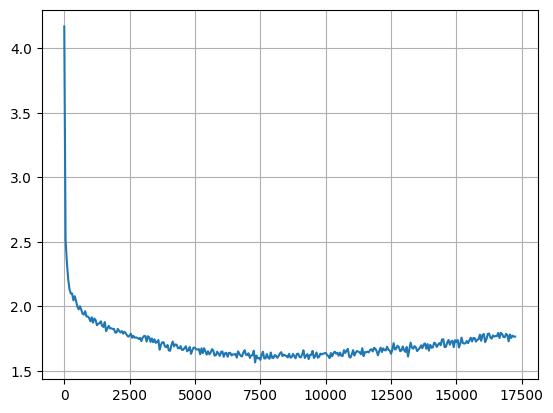

In [20]:
# 绘制训练 loss 曲线以直观观察模型收敛情况
# record["train"][::50]：每隔 50 步采样一个数据点，避免绘制全量数据时折线过于密集
# 列表推导式分别提取 step（横轴：训练步数）和 loss（纵轴：交叉熵损失值）
plt.plot(
    [i["step"] for i in record["train"][::50]],  # 横轴：每隔 50 步的全局步数（int）
    [i["loss"] for i in record["train"][::50]],  # 纵轴：对应步数的交叉熵损失（float）
    label="train"                                # 图例标签，标注该曲线为训练集 loss
)
plt.grid()   # 显示网格线，便于读取具体数值
plt.show()   # 渲染并显示图表

## 四、推理与文本生成

### 4.1 温度（Temperature）采样原理演示

In [21]:
# 演示温度（temperature）参数对 softmax 概率分布的影响
# 温度是文本生成中控制"随机性"的关键超参数：
#   - temperature 低（趋近 0）：概率向最大 logit 集中，生成更确定、保守的文本
#   - temperature 高（趋近 ∞）：概率趋于均匀分布，生成更随机、多样的文本
# 等价于：logits_scaled = logits / temperature，然后对 logits_scaled 做 softmax

# 当 logits 差异极大时（如 400 vs 600），softmax 结果几乎为 one-hot（完全确定）
logits = torch.tensor([400.0, 600.0])  # 构造一组差距极大的 logits（单位：任意），dtype=float32

probs1 = F.softmax(logits, dim=-1)  # dim=-1 表示对最后一维（此处唯一维度）做 softmax 归一化
print(probs1)  # 预期输出接近 [0., 1.]，说明模型几乎完全确信选第二个字符

tensor([0., 1.])


In [22]:
# 演示提高温度后（即除以较大的 temperature 值）概率分布趋于均匀
# 原始 logits [400, 600] 除以 temperature=10000 后近似为 [0.04, 0.06]
# 此时两个 logits 差距缩小，softmax 输出接近 [0.5, 0.5]，即两个字符被选中的概率相近
logits = torch.tensor([0.04, 0.06])  # 模拟高温度采样后的缩放 logits（相当于原始 logits / 10000）

probs1 = F.softmax(logits, dim=-1)  # 对缩放后的 logits 做 softmax 归一化
print(probs1)  # 预期输出接近 [0.495, 0.505]，两类概率非常接近，采样结果更随机多样

tensor([0.4950, 0.5050])


### 4.2 多项分布（Multinomial）采样演示

In [23]:
import torch  # 已在顶部导入，此处重复导入无副作用，仅为明确本 cell 的依赖

# 演示 torch.multinomial() 函数：按概率分布进行随机采样
# 文本生成时，模型输出的 softmax 概率即为此处的 prob_dist
# multinomial 采样确保概率大的字符更频繁被选中，同时保留随机性（不会永远只选最大值）

# 构造一个四类别的概率分布（各元素之和应为 1.0）
# 类别 0: 10%，类别 1: 45%，类别 2: 35%，类别 3: 10%
prob_dist = torch.tensor([0.1, 0.45, 0.35, 0.1])

# torch.multinomial(input, num_samples, replacement=False) 参数说明：
#   input (Tensor): 每个类别的权重或概率，无需归一化（函数内部会归一化）
#   num_samples (int): 每次抽取的样本数量，文本生成时通常为 1（逐字符生成）
#   replacement (bool, 默认 False): 有放回/无放回抽样开关
#       True  → 有放回抽样，同一类别可被多次抽到
#       False → 无放回抽样，每个类别最多被选 1 次（num_samples 不能超过非零类别数）
# num_samples 与返回值形状的关系（input 为 1D 向量时）：
#   num_samples=1  → 返回 shape=(1,)  的 LongTensor，含 1 个类别索引
#   num_samples=5  → 返回 shape=(5,)  的 LongTensor，含 5 个类别索引
#   num_samples=N  → 返回 shape=(N,)  的 LongTensor，含 N 个类别索引
# 若 input 为 2D 矩阵 (batch, num_classes)，则返回 shape=(batch, num_samples)
num_samples = 5  # 演示用：设为 5 时下方应传入 num_samples 而非 1，此处仍用 1 展示单样本场景

# 从 prob_dist 中有放回地抽取 1 个样本索引（显式写 replacement=True 覆盖默认的 False）
# 返回值 samples: LongTensor，shape=(num_samples,)，此处 num_samples=1 故 shape=(1,)
samples = torch.multinomial(prob_dist, 1, replacement=True)

print("概率分布:", prob_dist)                      # 打印原始概率分布向量
print("抽取的样本索引:", samples)                  # 打印被选中的类别索引（int64 张量）

# 通过被选中的索引反查对应的概率值，验证采样结果与概率的关联性
print("每个样本对应的概率:", prob_dist[samples])

概率分布: tensor([0.1000, 0.4500, 0.3500, 0.1000])
抽取的样本索引: tensor([1])
每个样本对应的概率: tensor([0.4500])


### 4.3 文本生成函数与推理示例

In [31]:
def generate_text(model, start_string, max_len=1000, temperature=1.0, stream=True):
    """
    使用训练好的 CharRNN 模型自回归生成文本。

    参数：
        model (nn.Module): 已加载检查点权重的 CharRNN 模型
        start_string (str): 初始提示字符串，作为生成的"种子"输入（可以是任意字符序列）
        max_len (int): 最多生成的字符数量，默认 1000
        temperature (float): 温度参数，控制生成随机性；
                             < 1.0 时输出更保守（文本更流畅但重复）；
                             > 1.0 时输出更随机（文本更多样但可能不连贯）
        stream (bool): True 时边生成边打印字符（流式输出）；False 时静默生成

    返回：
        str: 生成的字符串（不含 start_string 部分），长度为 max_len
    """
    # 将提示字符串编码为整数 ID 序列，然后转为 int64 张量并移至目标设备
    # reshape(1, -1) 添加 batch 维度：(seq_len,) → (1, seq_len)，满足模型输入格式
    input_eval = torch.Tensor([char2idx[char] for char in start_string]).to(
        dtype=torch.int64, device=device
    ).reshape(1, -1)

    hidden = None          # 初始隐藏状态为 None，RNN 将从全零状态开始
    text_generated = []    # 存储生成的字符 ID 列表，最终转换为字符串返回
    model.eval()           # 切换为推理模式：关闭 Dropout，固定 BatchNorm 统计量

    print(start_string, end="")  # 先打印提示字符串，后续生成内容紧接其后

    # torch.no_grad() 上下文管理器：禁止计算梯度，节省显存并加速推理
    # 推理阶段不需要反向传播，所以不需要保存中间激活值
    with torch.no_grad():
        for i in range(max_len):  # 每次循环生成一个字符
            # 前向传播：input_eval 形状为 (1, current_seq_len)
            # logits 形状为 (1, current_seq_len, vocab_size)
            # hidden 形状为 (1, 1, hidden_dim)，保留用于下一步传入
            logits, hidden = model(input_eval, hidden=hidden)

            # 温度采样：将最后一个时间步的 logits 除以 temperature
            # logits[0, -1, :] 取出形状 (vocab_size,) 的 1D 向量（只需预测下一个字符）
            # 除以 temperature > 1 会"压平"概率分布；除以 temperature < 1 会"锐化"分布
            logits = logits[0, -1, :] / temperature

            # F.softmax 将 logits 转换为合法的概率分布（各元素非负且求和为 1）
            # dim=-1 表示对最后一维（vocab_size 维）归一化
            probs = F.softmax(logits, dim=-1)

            # torch.multinomial(probs, num_samples, replacement=False) 按概率分布随机抽样
            #   num_samples=1 → 返回 shape=(1,) 的 LongTensor；.item() 取出唯一的 Python int 索引
            #   num_samples=N → 返回 shape=(N,) 的张量（本循环逐字生成，故固定为 1）
            #   replacement 默认为 False（无放回）；num_samples=1 时有无放回效果相同
            idx = torch.multinomial(probs, 1).item()

            # 将新生成的字符 ID 转为 (1,1) 形状的张量，作为下一步的输入
            # 这是"自回归"的核心：每次只输入上一步生成的单个字符，利用 hidden 保留历史信息
            input_eval = torch.Tensor([idx]).to(dtype=torch.int64, device=device).reshape(1, -1)

            text_generated.append(idx)  # 将字符 ID 加入生成列表

            if stream:
                # flush=True 强制立即刷新输出缓冲区，确保字符实时打印（流式显示效果）
                print(idx2char[idx], end="", flush=True)

    # 将字符 ID 列表通过 idx2char 数组转换回字符，再拼接为完整字符串
    return "".join([idx2char[i] for i in text_generated])

model = CharRNN(vocab_size=vocab_size)              #重新实例化初始模型，以导入权重
model.to(device)  # 模型移动到device
# 从检查点文件加载训练好的模型权重
# weights_only=True：只加载权重张量，不反序列化任意 Python 对象（安全最佳实践）
# map_location="cpu"：将所有张量映射到 CPU，避免在无 GPU 环境下因设备不匹配而报错
model.load_state_dict(
    torch.load("model_checkpoints/4_model/4_model_best.ckpt", weights_only=True, map_location="cpu")
)

start_string = "Hello: "  # 初始提示字符串，可以是剧本中任意合法的字符序列
# 调用生成函数：生成 1000 个字符，温度 0.5（较低温度使输出更流畅稳定）
res = generate_text(model, start_string, max_len=1000, temperature=0.45, stream=True)

Hello: I am no prince
And send him stand upon your king,
And doth some other sake, this a soul of you a traitor to the sun
When he rounds a sight and private wretched as many a thousand stronger than to that ends as well as if
I know not what you have been an end.

LORDS:
Then, gentle Romeo, his contract and second condemn'd by this night.

ROMEO:
As much thoughts are but by my heart,
And say 'tis not the stroke of banishment
And then this crown it is come to the watery dreams.

KING RICHARD II:
What say you to him.

First Senator:
This is the right of the balm to pricentio.

LUCENTIO:
And so it is the cause of the foot,
And so turn the stomach of another,
That any other battle be my wife and talk'd of an entreaties
That thou shalt be her sister shall be to supply the trumpets, and be proints?
For what we were a most prosperous
all gentlemen, and so my son Aumerle.

SICINIUS:
We will be believe
He shall be the people granted that thou hast broke the senate to this business.

KING RICHA

In [32]:
# 查看变量 res 的内容：generate_text 函数的返回值
# res 是一个 Python 字符串（str），包含模型生成的 1000 个字符
# 在 Jupyter Notebook 中，cell 最后一行的表达式结果会自动显示在输出区域
print(res)

I am no prince
And send him stand upon your king,
And doth some other sake, this a soul of you a traitor to the sun
When he rounds a sight and private wretched as many a thousand stronger than to that ends as well as if
I know not what you have been an end.

LORDS:
Then, gentle Romeo, his contract and second condemn'd by this night.

ROMEO:
As much thoughts are but by my heart,
And say 'tis not the stroke of banishment
And then this crown it is come to the watery dreams.

KING RICHARD II:
What say you to him.

First Senator:
This is the right of the balm to pricentio.

LUCENTIO:
And so it is the cause of the foot,
And so turn the stomach of another,
That any other battle be my wife and talk'd of an entreaties
That thou shalt be her sister shall be to supply the trumpets, and be proints?
For what we were a most prosperous
all gentlemen, and so my son Aumerle.

SICINIUS:
We will be believe
He shall be the people granted that thou hast broke the senate to this business.

KING RICHARD III: